Matplotlib is building the font cache; this may take a moment.


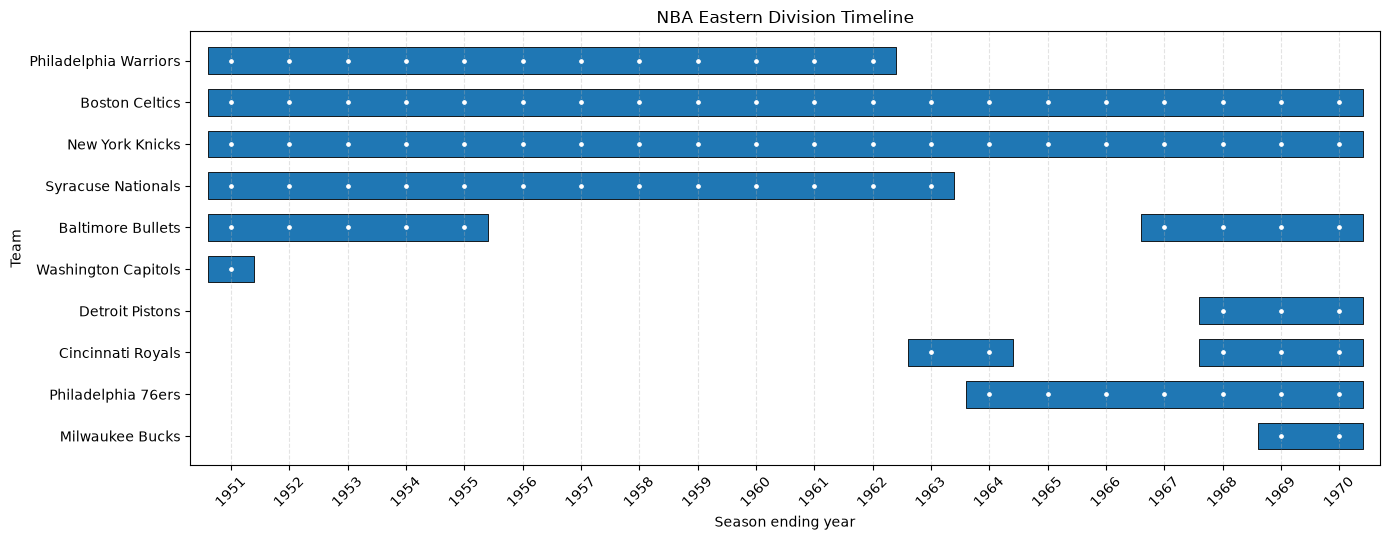

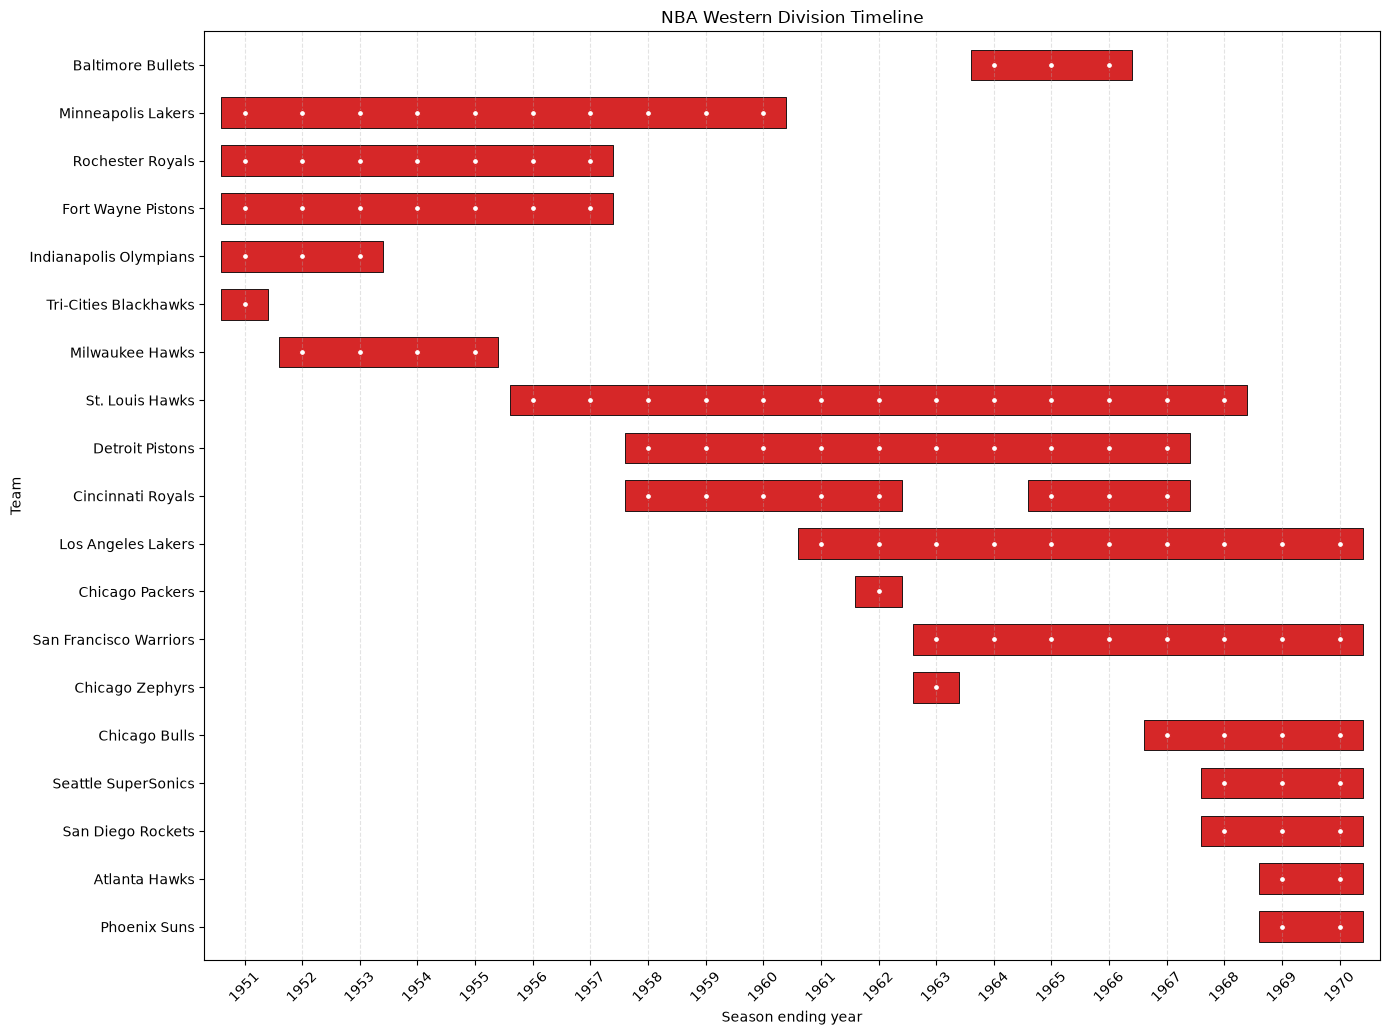

In [2]:
import matplotlib.pyplot as plt
from itertools import groupby
from operator import itemgetter

division_mapping = {
    "Philadelphia Warriors" : {
        "eastern" : [
            1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
            1962
        ],
    },
    "Boston Celtics" : {
        "eastern" : [
            1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
            1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970
        ],
    },
    "New York Knicks" : {
        "eastern" : [
            1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
            1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970
        ],
    },
    "Syracuse Nationals" : {
        "eastern" : [
            1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
            1962, 1963
        ],
    },
    "Baltimore Bullets" : {
        "eastern" : [1951, 1952, 1953, 1954, 1955, 1967, 1968, 1969, 1970],
        "western" : [1964, 1965, 1966],
    },
    "Washington Capitols" : {
        "eastern" : [1951],
    },
    "Minneapolis Lakers" : {
        "western" : [1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960],
    },
    "Rochester Royals" : {
        "western" : [1951, 1952, 1953, 1954, 1955, 1956, 1957],
    },
    "Fort Wayne Pistons" : {
        "western" : [1951, 1952, 1953, 1954,  1955, 1956, 1957],
    },
    "Indianapolis Olympians" : {
        "western" : [1951, 1952, 1953],
    },
    "Tri-Cities Blackhawks" : {
        "western" : [1951],
    },
    "Milwaukee Hawks" : {
        "western" : [1952, 1953, 1954, 1955],
    },
    "St. Louis Hawks" : {
        "western" : [
            1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966,
            1967, 1968
        ],
    },
    "Detroit Pistons" : {
        "western" : [
            1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967
        ],
        "eastern" : [1968, 1969, 1970],
    },
    "Cincinnati Royals" : {
        "western" : [1958, 1959, 1960, 1961, 1962, 1965, 1966, 1967],
        "eastern" : [1963, 1964, 1968, 1969, 1970],
    },
    "Los Angeles Lakers" : {
        "western" : [
            1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
            1970
        ],
    },
    "Chicago Packers" : {
        "western" : [1962],
    },
    "San Francisco Warriors" : {
        "western" : [1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970],
    },
    "Chicago Zephyrs" : {
        "western" : [1963],
    },
    "Philadelphia 76ers" : {
        "eastern" : [1964, 1965, 1966, 1967, 1968, 1969, 1970],
    },
    "Chicago Bulls" : {
        "western" : [1967, 1968, 1969, 1970],
    },
    "Seattle SuperSonics" : {
        "western" : [1968, 1969, 1970],
    },
    "San Diego Rockets" : {
        "western" : [1968, 1969, 1970],
    },
    "Milwaukee Bucks" : {
        "eastern" : [1969, 1970],
    },
    "Atlanta Hawks" : {
        "western" : [1969, 1970],
    },
    "Phoenix Suns" : {
        "western" : [1969, 1970]
    }
}

def consecutive_ranges(years):
    """Convert years into continuous ranges, preserving gaps."""
    years = sorted(set(years))

    for _, group in groupby(
        enumerate(years),
        key=lambda item: item[1] - item[0],
    ):
        group_years = [item[1] for item in group]
        yield min(group_years), max(group_years)


def plot_division_timeline(division_mapping, division):
    teams = [
        team
        for team, divisions in division_mapping.items()
        if division in divisions
    ]

    fig_height = max(5, len(teams) * 0.55)
    fig, ax = plt.subplots(figsize=(14, fig_height))

    color = "#1f77b4" if division == "eastern" else "#d62728"

    for y_position, team in enumerate(teams):
        years = division_mapping[team][division]

        # Draw each uninterrupted run separately so missing years remain visible.
        for start_year, end_year in consecutive_ranges(years):
            ax.broken_barh(
                [(start_year - 0.4, end_year - start_year + 0.8)],
                (y_position - 0.32, 0.64),
                facecolors=color,
                edgecolors="black",
                linewidth=0.6,
            )

        # Add a marker for every individual season.
        ax.scatter(
            years,
            [y_position] * len(years),
            color="white",
            edgecolor=color,
            linewidth=0.8,
            s=18,
            zorder=3,
        )

    all_years = [
        year
        for team in teams
        for year in division_mapping[team][division]
    ]

    ax.set_yticks(range(len(teams)))
    ax.set_yticklabels(teams)
    ax.set_xticks(range(min(all_years), max(all_years) + 1))
    ax.set_xlim(min(all_years) - 0.7, max(all_years) + 0.7)
    ax.set_ylim(-0.7, len(teams) - 0.3)

    ax.set_title(f"NBA {division.title()} Division Timeline")
    ax.set_xlabel("Season ending year")
    ax.set_ylabel("Team")
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.invert_yaxis()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Assumes your dictionary is named division_mapping.
plot_division_timeline(division_mapping, "eastern")
plot_division_timeline(division_mapping, "western")